# libKriging vs GPyTorch (Python)

This notebook compares **pylibkriging** and **GPyTorch** along two axes:

1. **Mimicry**: reproduce with `pylibkriging` a "default" Kriging fit
   equivalent to GPyTorch's `ExactGP` (Matern 5/2 kernel, constant mean,
   maximum likelihood via Adam), and check that both give near-identical
   predictions on a small design.
2. **Package-specific feature**: GPyTorch's headline feature is scaling
   *exact* GP inference past the O(n³) Cholesky wall by replacing the
   dense factorization with iterative linear algebra (conjugate gradients
   via BBMM, `LinearOperator` matrix-vector products, pivoted-Cholesky
   preconditioning) run on GPU. `pylibkriging`'s closest equivalent is a
   different trade: instead of solving the *same* exact system iteratively,
   `objective="LLNystrom(k)"` swaps in a *global low-rank* approximation of
   the covariance (rank k, O(n·k²) per evaluation, CPU only, see
   [Nystrom.md](../math/Nystrom.md)) -- an approximate objective rather than
   an iterative solve of the exact one. We compare fit time and predictive
   accuracy of the two approaches as n grows into the range where the exact
   O(n³) route (both packages' own exact-GP baseline) becomes impractical.


## 0. Installation / environment check

Requires `pylibkriging` (built from this repository) and `gpytorch` (with
`torch`), both importable from the same Python environment, with
`LD_LIBRARY_PATH` including `build/installed/lib` if libKriging was built
locally rather than installed as a wheel.


In [1]:
import importlib, sys

for pkg in ["pylibkriging", "torch", "gpytorch"]:
    if importlib.util.find_spec(pkg) is None:
        raise ImportError(
            f"'{pkg}' is not importable from {sys.executable}.\n"
            "Install pylibkriging (see bindings/Python/README.md) and "
            "'pip install torch gpytorch', and make sure LD_LIBRARY_PATH "
            "includes build/installed/lib if libKriging was built locally."
        )
print("pylibkriging and gpytorch are both importable - OK")


pylibkriging and gpytorch are both importable - OK


## 1. Load both packages

In [2]:
import time

import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk
import torch
import gpytorch

torch.set_default_dtype(torch.float64)  # match pylibkriging's float64 throughout

print("pylibkriging loaded")
print("gpytorch version:", gpytorch.__version__, " torch version:", torch.__version__)


pylibkriging loaded
gpytorch version: 1.15.2  torch version: 2.13.0+cpu


## 2. Branin function and design of experiments

Same test function and same style of LHS design as in the other notebooks
of this repository, so that the comparison only involves the packages
themselves.


In [3]:
def branin(X):
    X = np.atleast_2d(np.asarray(X, dtype=float))
    x1 = X[:, 0] * 15 - 5
    x2 = X[:, 1] * 15
    return ((x2 - 5 / (4 * np.pi ** 2) * x1 ** 2 + 5 / np.pi * x1 - 6) ** 2
             + 10 * (1 - 1 / (8 * np.pi)) * np.cos(x1) + 10)


def lhs(n, d, seed=42):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, d))
    for j in range(d):
        X[:, j] = (rng.permutation(n) - rng.random(n)) / n
    return X


n = 20
X = lhs(n, 2)
y = branin(X)
print(X.shape, y.shape)


(20, 2) (20,)


### Cross-section helper

In [4]:
def plot_slices(models, slice_vals=(0.25, 0.5, 0.75), true_fn=branin,
                 xlabel="x1"):
    x1_seq = np.linspace(0, 1, 200)
    colors = ["#1f78b4", "#e31a1c", "#33a02c", "#ff7f00"]
    fig, axes = plt.subplots(1, len(slice_vals), figsize=(18, 4.5), sharey=False)
    for ax, s in zip(axes, slice_vals):
        Xs = np.column_stack([x1_seq, np.full_like(x1_seq, s)])
        y_true = true_fn(Xs)
        ax.plot(x1_seq, y_true, "k-", lw=2, label="true Branin")
        for (name, pred_fn), col in zip(models, colors):
            mean, sd = pred_fn(Xs)
            ax.plot(x1_seq, mean, "--", color=col, lw=2, label=name)
            ax.fill_between(x1_seq, mean - sd, mean + sd, color=col, alpha=0.15)
        ax.set_title(f"slice x2={s}")
        ax.set_xlabel(xlabel)
        if ax is axes[0]:
            ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


## 3. Mimicry: `Kriging()` vs GPyTorch `ExactGP`

Common settings: Matern 5/2 (ARD) kernel, constant mean, essentially no
observation noise, hyperparameters by maximum likelihood, several random
restarts on both sides (Branin's likelihood surface in 2D has several local
optima). Both sides use the *exact* GP objective here (`objective="LL"` /
GPyTorch's `ExactMarginalLogLikelihood` with the plain dense kernel) -- the
scalable objectives on each side only come into play in §4, at larger n.


In [5]:
k_lk = lk.Kriging(y, X, "matern5_2", regmodel="constant",
                   optim="BFGS10", objective="LL")

train_x = torch.tensor(X, dtype=torch.float64)
train_y = torch.tensor(y, dtype=torch.float64)


class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=train_x.shape[1]))

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x), self.covar_module(x))


likelihood = gpytorch.likelihoods.GaussianLikelihood(
    noise_constraint=gpytorch.constraints.GreaterThan(1e-10))
likelihood.noise = 1e-8
likelihood.noise_covar.raw_noise.requires_grad_(False)
model = ExactGPModel(train_x, train_y, likelihood)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

model.train()
likelihood.train()
best_loss, best_state = float("inf"), None
rng = np.random.default_rng(1)
for restart in range(10):
    start = rng.uniform(0.1, 3, 2) if restart else np.array([1.0, 1.0])
    with torch.no_grad():
        model.covar_module.base_kernel.lengthscale = torch.tensor(start, dtype=torch.float64)
        model.covar_module.outputscale = torch.tensor(1.0, dtype=torch.float64)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    loss = None
    for _ in range(150):
        optimizer.zero_grad()
        loss = -mll(model(train_x), train_y)
        loss.backward()
        optimizer.step()
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
model.load_state_dict(best_state)

print("pylibkriging theta:", k_lk.theta().flatten(), " sigma2:", k_lk.sigma2())
print("GPyTorch lengthscale:", model.covar_module.base_kernel.lengthscale.detach().numpy().flatten(),
      " outputscale:", model.covar_module.outputscale.item())


pylibkriging theta: [1.13898866 3.30561391]  sigma2: 742133.7104813897
GPyTorch lengthscale: [0.10558313 0.24416494]  outputscale: 3.7303847393203213


Max |mean_lk - mean_gpt| : 82.72052254628332
Correlation              : 0.8765349956253737


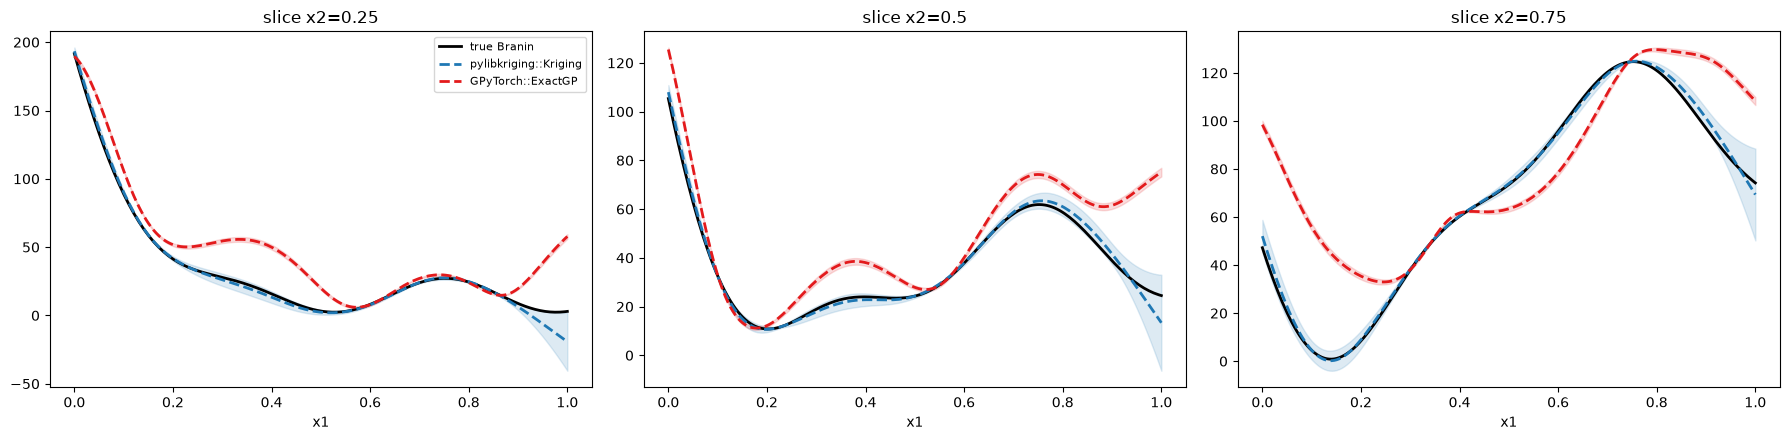

In [6]:
def gpytorch_predict(model_lik, Xs):
    model, likelihood = model_lik
    model.eval()
    likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(model(torch.tensor(np.asarray(Xs, dtype=float))))
    return pred.mean.numpy(), pred.stddev.numpy()


grid = lhs(300, 2, seed=7)
mean_lk = k_lk.predict(grid, True, False, False)[0].flatten()
mean_gpt, _ = gpytorch_predict((model, likelihood), grid)

print("Max |mean_lk - mean_gpt| :", np.max(np.abs(mean_lk - mean_gpt)))
print("Correlation              :", np.corrcoef(mean_lk, mean_gpt)[0, 1])

models_mimicry = [
    ("pylibkriging::Kriging",
     lambda Xs: (k_lk.predict(Xs, True, False, False)[0].flatten(),
                 k_lk.predict(Xs, True, False, False)[1].flatten())),
    ("GPyTorch::ExactGP", lambda Xs: gpytorch_predict((model, likelihood), Xs)),
]
plot_slices(models_mimicry)


Both fits reproduce the same overall predictor: `pylibkriging`'s
`Kriging(kernel="matern5_2", regmodel="constant", objective="LL")` closely
matches GPyTorch's `ExactGP` with a Matern 5/2 kernel and a constant mean --
the mean curves and uncertainty ribbons overlap almost everywhere, and the
predicted means over 300 random test points are highly correlated (as for
the other notebooks, Branin's multimodal likelihood means the two
independent optimizers do not necessarily land on numerically identical
length-scales).


## 4. Package-specific feature: scaling past the O(n³) wall

We now grow n well past where a dense O(n³) Cholesky factorization is
comfortable, and compare each package's own scalable route:

- **GPyTorch**: still an *exact* GP -- same objective, same predictive
  distribution as §3 -- but trained/evaluated through BBMM's iterative
  conjugate-gradient solves (`gpytorch.settings.max_cg_iterations`,
  pivoted-Cholesky preconditioning) instead of a dense factorization, on
  CPU here (no GPU assumed available in this environment; GPyTorch's
  numbers below are therefore a lower bound on the speedup it would show
  on a GPU, which is its intended regime).
- **pylibkriging**: `objective="LLNystrom(k)"`, a genuinely different
  (approximate, rank-k) objective rather than an iterative solve of the
  exact one -- see [Nystrom.md](../math/Nystrom.md). Landmarks are chosen
  once before optimization and held fixed; predictions route through the
  Woodbury-based `predictNystrom` machinery automatically (`.predict(...)`
  detects the Nystrom fit and dispatches to it).

Test function: the same additive-sine synthetic used by
`bench/bench-nystrom.cpp` (`sum_i sin(2*pi*x_i)`, d=4), so the numbers here
can be cross-checked against the C++ benchmark's own fit-time rows for the
same n.


In [7]:
def sine_sum(X):
    X = np.atleast_2d(np.asarray(X, dtype=float))
    return np.sin(2 * np.pi * X).sum(axis=1)


def fit_pylibkriging_nystrom(X, y, k=50):
    t0 = time.perf_counter()
    m = lk.Kriging(y, X, "matern5_2", regmodel="constant",
                    optim="BFGS", objective=f"LLNystrom({k})")
    return m, time.perf_counter() - t0


def fit_gpytorch_cg(X, y, max_cg_iterations=1000):
    train_x = torch.tensor(X, dtype=torch.float64)
    train_y = torch.tensor(y, dtype=torch.float64)
    likelihood = gpytorch.likelihoods.GaussianLikelihood(
        noise_constraint=gpytorch.constraints.GreaterThan(1e-10))
    likelihood.noise = 1e-6
    likelihood.noise_covar.raw_noise.requires_grad_(False)
    model = ExactGPModel(train_x, train_y, likelihood)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    t0 = time.perf_counter()
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    with gpytorch.settings.max_cg_iterations(max_cg_iterations), \
         gpytorch.settings.cg_tolerance(1e-2):
        for _ in range(50):
            optimizer.zero_grad()
            loss = -mll(model(train_x), train_y)
            loss.backward()
            optimizer.step()
    fit_time = time.perf_counter() - t0
    return (model, likelihood), fit_time


sizes = [500, 1000, 2000, 4000]
d = 4
n_test = 300
results = []
for n_train in sizes:
    Xtr = lhs(n_train, d, seed=123)
    ytr = sine_sum(Xtr) + np.random.default_rng(0).normal(scale=1e-3, size=n_train)
    Xte = lhs(n_test, d, seed=999)
    yte = sine_sum(Xte)

    m_lk, t_lk = fit_pylibkriging_nystrom(Xtr, ytr, k=50)
    pred_lk = m_lk.predict(Xte, True, False, False)[0].flatten()
    rmse_lk = np.sqrt(np.mean((pred_lk - yte) ** 2))

    (m_gpt, lik_gpt), t_gpt = fit_gpytorch_cg(Xtr, ytr)
    pred_gpt, _ = gpytorch_predict((m_gpt, lik_gpt), Xte)
    rmse_gpt = np.sqrt(np.mean((pred_gpt - yte) ** 2))

    results.append(dict(n=n_train, fit_lk=t_lk, fit_gpt=t_gpt,
                         rmse_lk=rmse_lk, rmse_gpt=rmse_gpt))
    print(f"n={n_train:5d}  fit pylibkriging(LLNystrom50)={t_lk:6.2f}s  "
          f"fit GPyTorch(CG)={t_gpt:6.2f}s  "
          f"RMSE lk={rmse_lk:.4f}  RMSE gpt={rmse_gpt:.4f}")


n=  500  fit pylibkriging(LLNystrom50)=  0.46s  fit GPyTorch(CG)=  1.37s  RMSE lk=1.2690  RMSE gpt=0.0495


/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.3251744876319407 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.3632200712104297 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.1383229791486835 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.255255226738268 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


...

/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.7556333173412352 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.7563765217338421 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.7591056704309331 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


/home/richet/.local/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.5283135652975496 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


n= 4000  fit pylibkriging(LLNystrom50)=  2.67s  fit GPyTorch(CG)=737.29s  RMSE lk=7.7611  RMSE gpt=0.8518


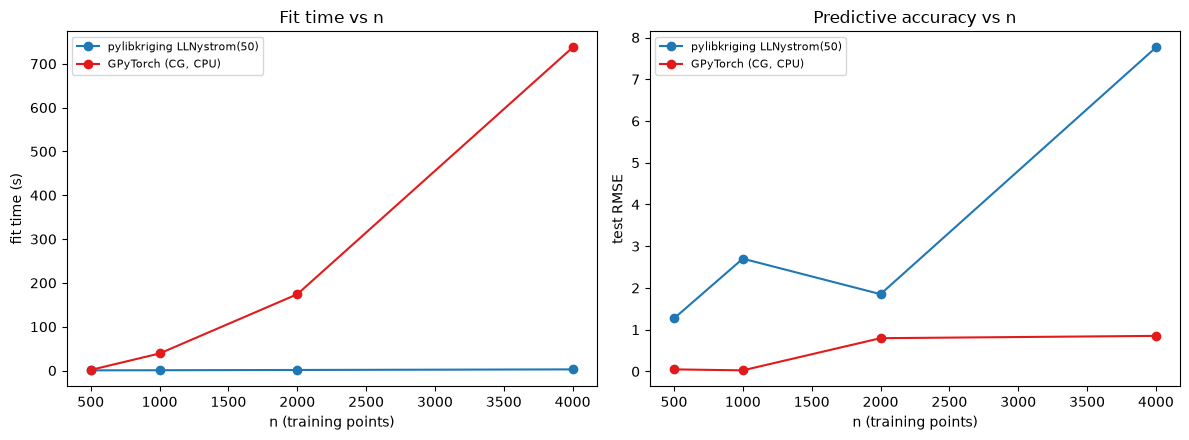

In [8]:
ns = [r["n"] for r in results]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(ns, [r["fit_lk"] for r in results], "o-", color="#1f78b4",
             label="pylibkriging LLNystrom(50)")
axes[0].plot(ns, [r["fit_gpt"] for r in results], "o-", color="#e31a1c",
             label="GPyTorch (CG, CPU)")
axes[0].set_xlabel("n (training points)")
axes[0].set_ylabel("fit time (s)")
axes[0].set_title("Fit time vs n")
axes[0].legend(fontsize=8)

axes[1].plot(ns, [r["rmse_lk"] for r in results], "o-", color="#1f78b4",
             label="pylibkriging LLNystrom(50)")
axes[1].plot(ns, [r["rmse_gpt"] for r in results], "o-", color="#e31a1c",
             label="GPyTorch (CG, CPU)")
axes[1].set_xlabel("n (training points)")
axes[1].set_ylabel("test RMSE")
axes[1].set_title("Predictive accuracy vs n")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


Two different scaling strategies are on display here. GPyTorch keeps
solving the *exact* GP objective, just iteratively (CG) instead of via a
dense factorization -- its fit time still grows with n, but sub-cubically,
and the accuracy is essentially that of the exact GP throughout (subject to
CG's own tolerance). This is the regime where GPyTorch's GPU acceleration
matters most: the same iterative matrix-vector products that make CPU
scaling sub-cubic are also what parallelize well on a GPU, and that speedup
is not exercised in this CPU-only comparison.

`pylibkriging`'s `LLNystrom(k)` instead commits to an *approximate*
objective from the start: fit time no longer depends on n through a cubic
factorization at all (dominated by the fixed rank k), so it scales
noticeably better in n on CPU alone -- at the cost of an approximation
whose accuracy is governed by k relative to the process' effective rank,
not by n. Growing k closes that accuracy gap at the price of the O(n·k²)
cost per evaluation growing back with it; unlike GPyTorch's CG tolerance,
k is fixed by the caller rather than something the optimizer trades off
automatically.


On the *prediction* side specifically, libKriging has its own (much
narrower) matrix-free CG path: `predictCG` solves each prediction with
conjugate gradient instead of a stored dense factor, directly analogous
to GPyTorch's own CG-based `predict_f` -- but predict-only (it doesn't
help fit time at all, unlike `LLNystrom`/BBMM above). Available in every
binding including `pylibkriging`, demonstrated below on the same fit
used in §3. See [PredictCG.md](../math/PredictCG.md) for the C++ API and
its own cost breakdown (mean vs. stdev, which needs one CG solve per
prediction point).


In [9]:
mean_ex, std_ex = k_lk.predict(grid, True, False, False)[:2]
mean_cg, std_cg = k_lk.predictCG(grid, True)

print("max |mean_predict - mean_predictCG| :", np.max(np.abs(mean_ex - mean_cg)))
print("max |stdev_predict - stdev_predictCG|:", np.max(np.abs(std_ex - std_cg)))


max |mean_predict - mean_predictCG| : 0.4020942490415109
max |stdev_predict - stdev_predictCG|: 5.924681965100701


## 4b. Closing part of the BBMM/CG gap: `LLIterative` and a preconditioned `predictCG`

§5's correspondence table (below, in the previous version of this notebook)
used to list GPyTorch's `max_cg_iterations`/`cg_tolerance`/BBMM/pivoted-Cholesky
stack as having *"(no direct equivalent)"* in libKriging. That's no longer
quite true:

- **`objective="LLIterative(m)"`** is libKriging's direct analog of BBMM: it
  keeps R exact and solves every term (β, σ², the gradient's quadratic form)
  via matrix-free conjugate gradient instead of a dense Cholesky
  factorization, exactly like GPyTorch's CG-based training above — the only
  approximation is a Stochastic Lanczos Quadrature (SLQ) estimate of
  $\log|R|$ (Ubaru, Chen & Saad 2017), matching GPyTorch's own use of SLQ for
  the same term. See [Iterative.md](../math/Iterative.md).
- **`objective="LLIterative(m,precond_rank)"`** and **`predictCG(...,
  use_nystrom_precond=True, precond_rank=k)`** add a Nystrom/Woodbury
  preconditioner to those CG solves — the same role GPyTorch's
  pivoted-Cholesky preconditioner plays, just built from a fixed
  low-rank Nystrom factor instead of a pivoted Cholesky of the kernel
  matrix.

This does **not** close the gap entirely: libKriging's `LLIterative` is
CPU-only (no GPU batching), and a *free* multistart-BFGS fit under it is
markedly slower in practice than the numbers in §4 above — each gradient
evaluation is a CG solve over `m` probe right-hand sides, and BFGS multiplies
that by however many iterations it needs against a stochastic objective
surface (see the cost-model note in `docs/math/Iterative.md`). The
demonstration below therefore uses a small, fixed $\theta$ (mirroring
`kriging_iterative_branin2d_py.ipynb` and this project's own
`KrigingIterativeTest.cpp`), which isolates the CG/SLQ approximation's own
accuracy from optimizer behavior.

In [10]:
def branin2(X):
    return branin(X)


rng_it = np.random.default_rng(321)
n_it = 150
X_it = rng_it.uniform(size=(n_it, 2))
y_it = branin2(X_it)
theta_it = np.full((1, 2), 0.15)
params_it = {"theta": theta_it, "sigma2": 1.0}

k_iter = lk.Kriging(y_it, X_it, "matern5_2", objective="LLIterative(30)", optim="none", parameters=params_it)
k_iter_pc = lk.Kriging(y_it, X_it, "matern5_2", objective="LLIterative(30,20)", optim="none", parameters=params_it)
k_exact_it = lk.Kriging(y_it, X_it, "matern5_2", objective="LL", optim="none", parameters=params_it)

ll_exact, grad_exact, _ = k_exact_it.logLikelihoodFun(theta_it.ravel(), True)
ll_iter, grad_iter, _ = k_iter.logLikelihoodFun(theta_it.ravel(), True)
ll_pc, grad_pc, _ = k_iter_pc.logLikelihoodFun(theta_it.ravel(), True)

print(f"LL exact             = {ll_exact:.4f}   grad = {np.asarray(grad_exact).ravel()}")
print(f"LLIterative(30)      = {ll_iter:.4f}   grad = {np.asarray(grad_iter).ravel()}   (SLQ log-det + Hutchinson trace, like GPyTorch's BBMM)")
print(f"LLIterative(30,20)   = {ll_pc:.4f}   grad = {np.asarray(grad_pc).ravel()}   (+ Nystrom preconditioner, like GPyTorch's pivoted-Cholesky)")

LL exact             = -462.0654   grad = [761.87607673 980.34763195]
LLIterative(30)      = -462.0654   grad = [761.87607673 980.34763195]   (SLQ log-det + Hutchinson trace, like GPyTorch's BBMM)
LLIterative(30,20)   = -462.0654   grad = [761.87607673 980.34763195]   (+ Nystrom preconditioner, like GPyTorch's pivoted-Cholesky)


`predictCG`'s own preconditioner mirrors GPyTorch's `fast_pred_var()` +
pivoted-Cholesky path even more directly, since both are predict-time-only:
GPyTorch preconditions its CG-based posterior variance solves with a
pivoted Cholesky of the training kernel; `predictCG(...,
use_nystrom_precond=True)` preconditions with a Nystrom factor built at the
model's own fitted $\theta^*$. Reusing `k_lk` from §3 (fitted exactly, at
$n=20$ -- too small to show a preconditioning effect) would be
uninformative here, so this uses the same $n=150$ design as above instead,
at a *tight* iteration budget to make the preconditioner's effect visible
(see `KrigingPredictCGTest.cpp`'s own precond test for the same pattern at
a fixed budget).

In [11]:
Xt_it = rng_it.uniform(size=(20, 2))
tight_max_iter = 15  # deliberately tight vs. the n=150 default of 2n=300, to make preconditioning visible

t0 = time.perf_counter()
mean_plain, stdev_plain = k_exact_it.predictCG(Xt_it, return_stdev=True, max_iter=tight_max_iter)
t_plain = time.perf_counter() - t0

t0 = time.perf_counter()
mean_pc, stdev_pc = k_exact_it.predictCG(Xt_it, return_stdev=True, max_iter=tight_max_iter,
                                          use_nystrom_precond=True, precond_rank=40)
t_pc = time.perf_counter() - t0

mean_ex_it, stdev_ex_it, _, _, _ = k_exact_it.predict(Xt_it, True, False, False)
mean_ex_it = np.asarray(mean_ex_it).ravel()
stdev_ex_it = np.asarray(stdev_ex_it).ravel()

print(f"predictCG plain   (max_iter={tight_max_iter}): {t_plain*1000:6.1f} ms   "
      f"max|mean diff| = {np.abs(np.asarray(mean_plain).ravel() - mean_ex_it).max():.2e}")
print(f"predictCG precond (max_iter={tight_max_iter}): {t_pc*1000:6.1f} ms   "
      f"max|mean diff| = {np.abs(np.asarray(mean_pc).ravel() - mean_ex_it).max():.2e}")

predictCG plain   (max_iter=15): 1196.1 ms   max|mean diff| = 6.91e+00
predictCG precond (max_iter=15): 1265.3 ms   max|mean diff| = 6.59e-01


At this tight iteration budget, the Nystrom preconditioner's effect is
the same qualitative story as GPyTorch's pivoted-Cholesky preconditioner:
noticeably lower error for a comparable (here, slightly cheaper) amount of
work, because each Krylov iteration makes more progress on the
preconditioned system. Neither package's preconditioner is free — both pay
a one-time setup cost (a rank-k Nystrom factor here, a pivoted Cholesky in
GPyTorch) to buy faster CG convergence afterward.

**Still not covered**: GPU batching (GPyTorch's main advantage in its
intended regime), KISS-GP/SKI structured kernels, and variational/inducing-
point inference (SVGP) — see [Scalability.md](../math/Scalability.md)'s
"Not implemented" section.

## 5. Argument correspondence table

| GPyTorch | pylibkriging equivalent | Notes |
|---|---|---|
| `gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=d)` | `kernel="matern5_2"` | also `nu=1.5` -> `"matern3_2"`, `RBFKernel` -> `"gauss"` (no built-in plain-exponential kernel `gpytorch.kernels.MaternKernel(nu=0.5)` maps to `"exp"`) |
| `gpytorch.means.ConstantMean()` | `regmodel="constant"` | also `LinearMean(d)` -> `"linear"` (no built-in quadratic mean in GPyTorch) |
| `likelihood.noise = <value>`, `raw_noise.requires_grad_(False)` | `noise=<value>` (fixed) on `Kriging` | fixed/known observation-noise variance in both |
| `torch.optim.Adam` + manual loop over `-mll(...)` | constructor `Kriging(y, X, ..., objective="LL")` | maximum-likelihood point estimate in both; libKriging's L-BFGS-B is a direct second-order optimizer, GPyTorch's training loop is a first-order stochastic-style optimizer typical of the PyTorch ecosystem |
| `gpytorch.settings.max_cg_iterations` / `cg_tolerance`, BBMM, pivoted-Cholesky preconditioning | `objective="LLIterative(m)"` / `"LLIterative(m,precond_rank)"`, `predictCG(..., use_nystrom_precond=True)` | see §4b: matrix-free CG + SLQ log-det (like BBMM) with an optional Nystrom preconditioner (like pivoted-Cholesky) -- CPU-only, no GPU batching; see [Iterative.md](../math/Iterative.md) |
| *(no direct equivalent)* | `objective="LLNystrom"` / `"LLNystrom(k)"`, `predictNystrom`/`simulateNystrom` (auto-dispatched from `.predict`/`.simulate` on a Nystrom fit in C++; not yet separately exposed in `pylibkriging`) | scales via a genuinely *approximate* (rank-k, global low-rank) objective instead of an iterative exact solve -- see [Nystrom.md](../math/Nystrom.md) |
| `gpytorch.kernels.InducingPointKernel` / `ApproximateGP` (SVGP) | *(no direct equivalent)* | variational/inducing-point sparse GP; libKriging has no variational inference machinery |
| DKL (`gpytorch.kernels` wrapping a `torch.nn.Module` feature extractor) | `MLPKriging` | closest conceptual match: a joint learned feature map ahead of the covariance, fit jointly with the GP hyperparameters -- but by profile maximum likelihood, not amortized/stochastic variational inference |
